**Etapa 1 — Modelo Base de Redes Neuronales**

En la primera fase el estudiante debe establecer una línea base de desempeño para el sistema.

**Actividades requeridas**
1. Seleccionar y documentar el dataset (fuente, tamaño, variables)
2. Realizar un Análisis Exploratorio de Datos (EDA)
3. Preparar los datos para entrenamiento
4. Construir un modelo neuronal base (MLP, red simple para clasificación o regresión)

**Métricas de evaluación**
• Accuracy, Precision, Recall, F1-score (clasificación)
• RMSE o MAE (regresión)


• [OPCIONAL] Visualización de curvas de pérdida y métricas durante el entrenamiento

• [OPCIONAL] Análisis de errores sobre ejemplos mal clasificados

In [1]:
# ============================================================
# PROYECTO: Predicción de Churn usando MLP + W&B Sweeps
# ============================================================
# Descripción:
# Este notebook implementa una red neuronal tipo MLP optimizada
# mediante búsqueda de hiperparámetros usando Weights & Biases Sweeps.
#
# Incluye:
# - Preprocesamiento
# - Definición de modelo parametrizable
# - Configuración de Sweep
# - Entrenamiento automatizado
# - Selección del mejor modelo
# ============================================================

# ==========================
# 1. LIBRERÍAS
# ==========================
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import wandb

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

#Ignorar warning
import warnings
warnings.filterwarnings('ignore')

print("Librerias cargadas correctamente")

Librerias cargadas correctamente


In [2]:
# ==========================
# 2. CONECTAR CON W&B
# ==========================

print(wandb.__version__)
wandb.login()



0.25.1


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\marlo\_netrc.
wandb: Currently logged in as: ingalex90 (ingalex90-universidad-don-bosco) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:

# ==========================
# 3. CARGA DE DATOS
# ==========================

archivo_final = 'datos_modelo_dl.npz'
loader = np.load(archivo_final)

# Cargamos los datos en memoria
X_train = loader['X_train']
y_train = loader['y_train']
X_val = loader['X_val']
y_val = loader['y_val']
X_test = loader['X_test']
y_test = loader['y_test']

#Verificar datos cargados
print(f"📊 Registros totales procesados: {len(X_train) + len(X_val) + len(X_test):,}")

📊 Registros totales procesados: 41,543


In [4]:
# ==========================
# 4. CLASS WEIGHTS
# ==========================

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

print(f"Pesos calculados para desbalanceo de clases: {class_weights}")

Pesos calculados para desbalanceo de clases: {np.int64(0): np.float64(0.6793908629441624), np.int64(1): np.float64(1.8936049801924166)}


In [5]:
# ==========================
# 5. FUNCIÓN DEL MODELO MLP
# ==========================

def build_model(config):
    """
    Construye un modelo MLP basado en configuración de W&B
    """

    model = models.Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))

    for _ in range(config.n_layers):
        model.add(layers.Dense(config.units, activation='relu'))
        model.add(layers.Dropout(config.dropout))

    model.add(layers.Dense(1, activation='sigmoid'))

    optimizer = tf.keras.optimizers.Adam(learning_rate=config.learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.AUC(name='AUC'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )

    return model

# ==========================
# 6. FUNCIÓN DE ENTRENAMIENTO
# ==========================

def train():
    """
    Función principal que ejecuta cada experimento del sweep
    """

    with wandb.init() as run:
        config = wandb.config

        model = build_model(config)

        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor='val_AUC',
            patience=5,
            mode='max',
            restore_best_weights=True
        )

        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=config.epochs,
            batch_size=config.batch_size,
            class_weight=class_weights,
            callbacks=[early_stop],
            verbose=0
        )

        # Evaluación final
        loss, auc, precision, recall = model.evaluate(X_val, y_val, verbose=0)

        # Log completo
        for epoch in range(len(history.history["loss"])):
            wandb.log({
                "epoch": epoch,
                "train_loss": history.history["loss"][epoch],
                "val_loss": history.history["val_loss"][epoch],
                "train_AUC": history.history["AUC"][epoch],
                "val_AUC": history.history["val_AUC"][epoch]
            })


In [6]:

# ==========================
# 7. CONFIGURACIÓN DEL SWEEP
# ==========================

sweep_config = {
    'method': 'random',
    'metric': {
        'name': 'val_AUC',
        'goal': 'maximize'
    },
    'parameters': {
        'n_layers': {
            'values': [1, 2, 3]
        },
        'units': {
            'values': [32, 64, 128]
        },
        'dropout': {
            'values': [0.1, 0.2, 0.3]
        },
        'learning_rate': {
            'values': [1e-2, 1e-3, 1e-4]
        },
        'batch_size': {
            'values': [32, 64, 128]
        },
        'epochs': {
            'value': 30
        }
    }
}

# ==========================
# 8. EJECUCIÓN DEL SWEEP - Busqqueda de hiperparametros optimos
# ==========================

sweep_id = wandb.sweep(sweep_config, project="churn-mlp-optimization")

# Ejecuta múltiples experimentos
wandb.agent(sweep_id, function=train, count=20)

Create sweep with ID: my3av7wp
Sweep URL: https://wandb.ai/ingalex90-universidad-don-bosco/churn-mlp-optimization/sweeps/my3av7wp


wandb: Agent Starting Run: d33h2j9h with config:
wandb: 	batch_size: 32
wandb: 	dropout: 0.3
wandb: 	epochs: 30
wandb: 	learning_rate: 0.001
wandb: 	n_layers: 2
wandb: 	units: 64
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\marlo\_netrc.


epoch,▁▁▂▂▂▃▃▃▄▄▅▅▅▆▆▆▇▇▇██
train_AUC,▁▄▅▅▆▇▇▇▇▇▇▇▇████████
train_loss,█▅▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val_AUC,▁▂▅▅▆▆▇▇▇▆▇▇▇█▇██▇▇██
val_loss,█▄▄▃▄▃▅▂▄▂▅▃▃▁▂▃▂▁▄▃▃
epoch,20
train_AUC,0.80626
train_loss,0.53049
val_AUC,0.81401
val_loss,0.51631


wandb: Agent Starting Run: jos2e6gl with config:
wandb: 	batch_size: 128
wandb: 	dropout: 0.1
wandb: 	epochs: 30
wandb: 	learning_rate: 0.01
wandb: 	n_layers: 3
wandb: 	units: 32
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\marlo\_netrc.


epoch,▁▂▂▃▄▄▅▅▆▇▇█
train_AUC,▁▅▆▆▇▇▇▇████
train_loss,█▄▃▂▂▂▂▁▁▁▁▁
val_AUC,▁▃▇▆▆▅█▇▇█▆▇
val_loss,█▇▂▄▄▅▁▃▄▃▁▃
epoch,11
train_AUC,0.80197
train_loss,0.53704
val_AUC,0.81064
val_loss,0.5249


...

epoch,▁▂▂▃▃▄▄▅▅▆▆▇▇█
train_AUC,▁▅▆▇▇▇▇███████
train_loss,█▄▃▃▂▂▂▁▂▂▁▁▁▁
val_AUC,▁▆▅▇▇▇▇▇█▇█▆▇█
val_loss,▁▂▃▁▂▅▁▄▂▁▂▅▂█
epoch,13
train_AUC,0.79299
train_loss,0.54763
val_AUC,0.81151
val_loss,0.6091


wandb: Agent Starting Run: vae1wvc8 with config:
wandb: 	batch_size: 128
wandb: 	dropout: 0.2
wandb: 	epochs: 30
wandb: 	learning_rate: 0.01
wandb: 	n_layers: 1
wandb: 	units: 32
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\marlo\_netrc.


epoch,▁▂▃▄▅▅▆▇█
train_AUC,▁▆▇▇▇█▇██
train_loss,█▃▂▂▂▂▂▁▁
val_AUC,▁▆▅█▇▆▇▇▇
val_loss,▇▅█▄▁▄▅▆▆
epoch,8
train_AUC,0.79599
train_loss,0.54352
val_AUC,0.80677
val_loss,0.54704


wandb: Agent Starting Run: cl8totw9 with config:
wandb: 	batch_size: 64
wandb: 	dropout: 0.3
wandb: 	epochs: 30
wandb: 	learning_rate: 0.001
wandb: 	n_layers: 1
wandb: 	units: 128
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\marlo\_netrc.


epoch,▁▁▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇██
train_AUC,▁▄▅▆▆▆▇▇▇▇▇▇▇▇█████████
train_loss,█▅▄▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val_AUC,▁▃▄▅▆▆▇▇▇▇▇▇▇▇▇▇████▇█▇
val_loss,█▆▅▃▅▄▃▂▃▄▃▁▂▄▂▁▃▃▃▂▁▂▁
epoch,22
train_AUC,0.80778
train_loss,0.53071
val_AUC,0.81004
val_loss,0.51554


# RESULTADO DE OPTIMIZACION 
Se obtienen de las 20 iteraciones realizadas que la iteración #12 consiguió la metrica val_AUC mas alta con los siguientes parametros:

![Mejores Métricas](images/WyB_best_metrics_iter_12.png)

Visualización de curva de perdida y metricas durante el entrenamiento

![Métricas](images/WyB_graficos_iter_12.png)

In [9]:
# ==========================
# 9. ENTRENAR MEJOR MODELO
# ==========================

# NOTA:
# El mejor modelo se identifica en la interfaz de W&B
# Luego puedes fijar manualmente los mejores hiperparámetros

best_config = {
    "batch_size":32,
    "dropout":0.3,
    "epochs":30,
    "learning_rate":0.001,
    "n_layers":3,
    "units":32
}

model = build_model(type("obj", (object,), best_config))

model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=best_config["epochs"],
    batch_size=best_config['batch_size'],
    class_weight=class_weights
)

# ==========================
# 10. EVALUACIÓN FINAL
# ==========================

loss, auc, precision, recall = model.evaluate(X_test, y_test)

print(f"Test AUC: {auc}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")


Epoch 1/30
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - AUC: 0.7243 - loss: 0.6159 - precision: 0.4054 - recall: 0.7054 - val_AUC: 0.7696 - val_loss: 0.5489 - val_precision: 0.4288 - val_recall: 0.7768
Epoch 2/30
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.7615 - loss: 0.5799 - precision: 0.4182 - recall: 0.8033 - val_AUC: 0.7825 - val_loss: 0.5464 - val_precision: 0.4241 - val_recall: 0.8425
Epoch 3/30
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.7685 - loss: 0.5708 - precision: 0.4201 - recall: 0.8151 - val_AUC: 0.7901 - val_loss: 0.5344 - val_precision: 0.4247 - val_recall: 0.8551
Epoch 4/30
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.7754 - loss: 0.5645 - precision: 0.4267 - recall: 0.8244 - val_AUC: 0.7926 - val_loss: 0.5218 - val_precision: 0.4332 - val_recall: 0.8213
Epoch 5/30
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.7795 - loss: 0.5589 - precision: 0.4289 - recall: 0.8309 - val_AUC: 0.7993 - val_loss: 0.5238 - val_precision: 0.4393 - val_recal

128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


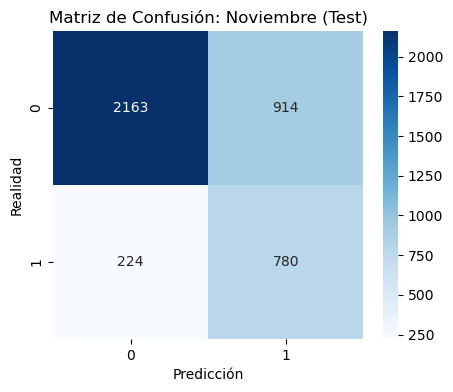

              precision    recall  f1-score   support

           0       0.91      0.70      0.79      3077
           1       0.46      0.78      0.58      1004

    accuracy                           0.72      4081
   macro avg       0.68      0.74      0.68      4081
weighted avg       0.80      0.72      0.74      4081



In [10]:
# Predecir sobre Test (Noviembre)
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión: Noviembre (Test)')
plt.ylabel('Realidad')
plt.xlabel('Predicción')
plt.show()

# Reporte detallado
print(classification_report(y_test, y_pred))